In [3]:
import pandas as pd
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df = df.dropna(subset=["CustomerID"])

In [9]:
#What percentage of transactions have no customer ID
df["CustomerID"].isnull().sum()

np.int64(0)

In [10]:
#How many cancelled invoices exist
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
cancelled.shape 

(8905, 8)

In [11]:
(df["Quantity"]<0).sum()

np.int64(8905)

In [12]:
(df["UnitPrice"]<0).sum()

np.int64(0)

In [13]:
df_clean = df.copy()
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[df_clean["Quantity"]>0]
df_clean = df_clean [df_clean["UnitPrice"]>0]

In [14]:
df_clean.shape

(397884, 8)

In [15]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Cleaning

The dataset contained cancellation transactions identified by invoice numbers beginning with "C".

These transactions were associated with negative quantities and represented returned or cancelled purchases rather than customer purchases.

Since the objective is to model customer purchasing behaviour and churn, cancellation transactions were removed from the analysis dataset.

In [16]:
df_clean["TotalPrice"] = (df_clean["Quantity"]* df_clean["UnitPrice"])

In [17]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [18]:
snapshot_date = df_clean["InvoiceDate"].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

In [19]:
rfm =df_clean.groupby("CustomerID").agg({"InvoiceDate":"max", "InvoiceNo":"nunique","TotalPrice":"sum"})
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,7,4310.00
12348.0,2011-09-25 13:13:00,4,1797.24
12349.0,2011-11-21 09:51:00,1,1757.55
12350.0,2011-02-02 16:01:00,1,334.40


In [20]:
rfm["Recency"] = (snapshot_date - rfm["InvoiceDate"]).dt.days
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice,Recency
CustomerID,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,325
12347.0,2011-12-07 15:52:00,7,4310.00,1
12348.0,2011-09-25 13:13:00,4,1797.24,74
12349.0,2011-11-21 09:51:00,1,1757.55,18
12350.0,2011-02-02 16:01:00,1,334.40,309


In [21]:
rfm["Churn"] = ( rfm["Recency"] >90).astype(int)
rfm["Churn"].value_counts()

Churn
0    2893
1    1445
Name: count, dtype: int64

In [22]:
(rfm["Churn"].value_counts(normalize=True)*100).round(4)

Churn
0    66.6897
1    33.3103
Name: proportion, dtype: float64

In [23]:
rfm.columns

Index(['InvoiceDate', 'InvoiceNo', 'TotalPrice', 'Recency', 'Churn'], dtype='object')

In [26]:
rfm.columns =["LastPurchase","Frequency","Monetary","Recency","Churn"]

In [27]:
rfm_model =rfm.drop(columns = ["LastPurchase"])
rfm_model.head()

,Frequency,Monetary,Recency,Churn
CustomerID,,,,
12346.0,1,77183.60,325,1
12347.0,7,4310.00,1,0
12348.0,4,1797.24,74,0
12349.0,1,1757.55,18,0
12350.0,1,334.40,309,1


In [28]:
rfm.groupby("Churn")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Churn,,,
0,30.894919,5.479087,2723.139932
1,212.945329,1.855363,715.130852


In [29]:
rfm.columns =["LastPurchase","Frequency","Monetary","Recency","Churn"]

In [30]:
X = rfm[["Frequency","Monetary"]]
y =rfm["Churn"]
X.head()

,Frequency,Monetary
CustomerID,,
12346.0,1,77183.60
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40


In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size =0.2,random_state=42)

In [32]:
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import classification_report 
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       561
           1       0.60      0.55      0.58       307

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868



In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Monetary,0.881723
0,Frequency,0.118277


<Figure size 800x500 with 0 Axes>

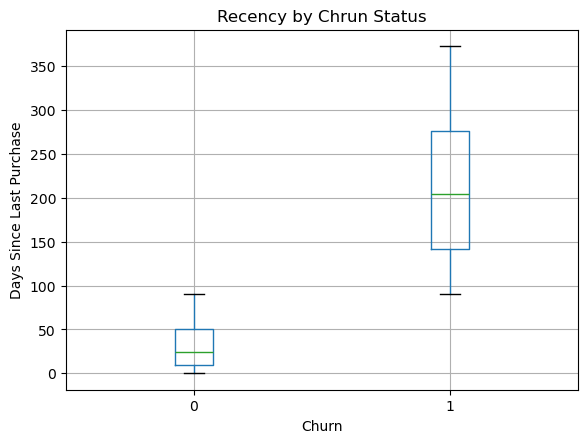

In [36]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,5))
rfm.boxplot(column ="Recency",by ="Churn")
plt.title("Recency by Chrun Status")
plt.suptitle("")
plt.ylabel("Days Since Last Purchase")
plt.show()

<Figure size 800x500 with 0 Axes>

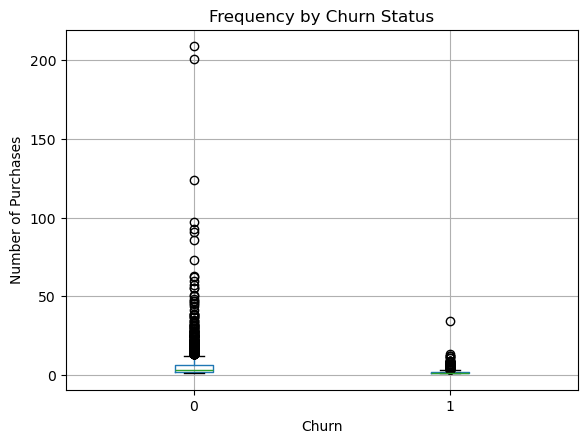

In [37]:
plt.figure(figsize=(8,5))
rfm.boxplot(column="Frequency", by="Churn")
plt.title("Frequency by Churn Status")
plt.suptitle("")
plt.ylabel("Number of Purchases")
plt.show()

<Figure size 800x500 with 0 Axes>

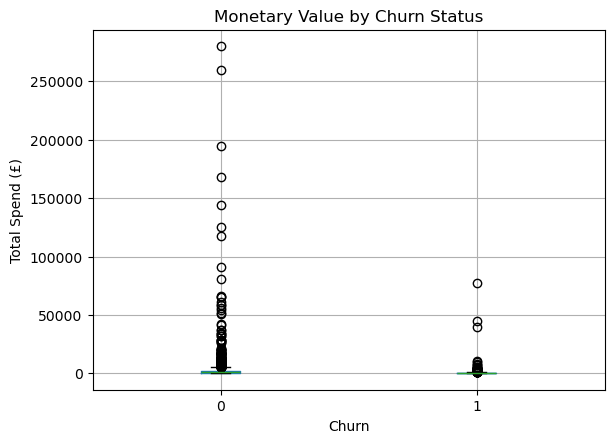

In [38]:
plt.figure(figsize=(8,5))
rfm.boxplot(column="Monetary", by="Churn")
plt.title("Monetary Value by Churn Status")
plt.suptitle("")
plt.ylabel("Total Spend (£)")
plt.show()

## Key Findings

1. Recency was the strongest predictor of churn.
2. Churned customers had significantly longer periods since their last purchase.
3. Active customers purchased more frequently.
4. Active customers spent substantially more money than churned customers.
5. A small number of high-value customers contributed disproportionately to revenue.

In [39]:
rfm["R_Score"] = pd.qcut(rfm["Recency"],4,labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),4,labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"],4,labels=[1,2,3,4])

In [40]:
rfm["RFM_Score"] = (rfm["R_Score"].astype(str) +rfm["F_Score"].astype(str) +rfm["M_Score"].astype(str))

In [41]:
rfm.sort_values(by=["R_Score","F_Score","M_Score"],ascending=False).head(10)

,LastPurchase,Frequency,Monetary,Recency,Churn,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,,
12980.0,2011-07-05 09:34:00,9,7374.90,157,1,1,4,4,144
13093.0,2011-03-09 12:14:00,8,7832.47,275,1,1,4,4,144
15235.0,2011-05-06 09:44:00,12,2247.51,217,1,1,4,4,144
15379.0,2011-06-23 13:13:00,7,3703.29,168,1,1,4,4,144
16553.0,2011-06-29 15:42:00,12,5719.82,162,1,1,4,4,144
16919.0,2011-07-06 13:35:00,11,2596.45,155,1,1,4,4,144
17230.0,2011-03-20 16:12:00,8,3638.41,263,1,1,4,4,144
17504.0,2011-05-17 12:59:00,9,2997.03,205,1,1,4,4,144
17850.0,2010-12-02 15:27:00,34,5391.21,371,1,1,4,4,144


In [51]:
def segment_customer(row):

    if row["R_Score"] == 4 and row["F_Score"] >= 3:
        return "Champion"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal"

    elif row["R_Score"] >= 3:
        return "Potential Loyalist"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Lost"

segment_order = [
    "Champion",
    "Loyal",
    "Potential Loyalist",
    "At Risk",
    "Lost"
]
rfm["Segment"] = rfm.apply(segment_customer,axis=1)
rfm["Segment"].value_counts().reindex(segment_order)




Segment
Champion               891
Loyal                  632
Potential Loyalist     665
At Risk                646
Lost                  1504
Name: count, dtype: int64

In [52]:
(rfm["Segment"].value_counts(normalize=True).mul(100).reindex(segment_order))

Segment
Champion              20.539419
Loyal                 14.568926
Potential Loyalist    15.329645
At Risk               14.891655
Lost                  34.670355
Name: proportion, dtype: float64

In [53]:
rfm.groupby("Segment")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2).reindex(segment_order)

,Recency,Frequency,Monetary
Segment,,,
Champion,7.10,10.46,5557.31
Loyal,30.34,5.81,2610.47
Potential Loyalist,24.25,1.45,754.82
At Risk,118.20,4.17,1611.35
Lost,185.57,1.25,510.07


In [54]:
rfm_export = rfm.reset_index()
rfm_export.to_csv("customer_segments.csv",index=False)

In [55]:
df_clean.to_csv("retail_transactions_clean.csv",index=False)